In [2]:
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Plot saved to ../results/failure_margins.png


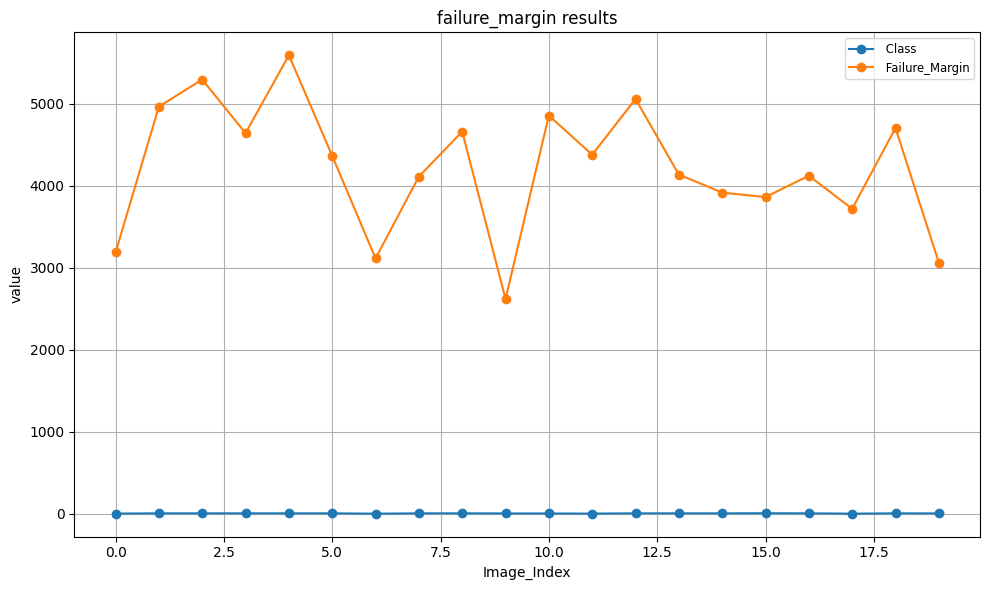

In [4]:

path = pathlib.Path("../results/failure_margins.txt")
if not path.exists():
    raise FileNotFoundError(f"{path} not found")

# Try to load with pandas, auto-detect separator, ignore comment lines
try:
    df = pd.read_csv(path, sep=None, engine="python", comment="#", skip_blank_lines=True)
except Exception:
    # fallback: whitespace-delimited
    df = pd.read_csv(path, sep=r"\s+", engine="python", comment="#", header=None)

# If no header (all column names are integers) try to infer header row if first row is non-numeric
if df.columns.dtype == "int64" or any(str(c).startswith("Unnamed") for c in df.columns):
    # try reading first non-comment line as header
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            # if any part is non-numeric, treat it as header
            if any(not _.replace(".","",1).lstrip("-").isdigit() for _ in parts):
                df = pd.read_csv(path, sep=None, engine="python", comment="#", header=0)
            break

# Keep only numeric columns for plotting
num_df = df.select_dtypes(include=[np.number])
if num_df.empty:
    raise ValueError("No numeric columns found in file to plot")

# Choose x axis: use first column if it's numeric and looks like index/time, otherwise use the dataframe index
x_col = None
first_col = num_df.columns[0]
if num_df.shape[1] > 1:
    # if the first column has increasing values, use it as x
    vals = num_df.iloc[:, 0].values
    if np.all(np.isfinite(vals)) and (np.all(np.diff(vals) >= 0) or np.all(np.diff(vals) <= 0)):
        x_col = num_df.columns[0]
    else:
        x_col = None

plt.figure(figsize=(10, 6))
if x_col is not None and num_df.shape[1] > 1:
    x = num_df[x_col]
    for col in num_df.columns:
        if col == x_col:
            continue
        plt.plot(x, num_df[col], marker='o', label=str(col))
    plt.xlabel(str(x_col))
else:
    # plot each column vs index
    for col in num_df.columns:
        plt.plot(num_df.index, num_df[col], marker='o', label=str(col))
    plt.xlabel("row index")

plt.ylabel("value")
plt.title("failure_margin results")
plt.grid(True)
plt.legend(loc="best", fontsize="small")
plt.tight_layout()

# save a copy next to the data file
out_png = path.with_suffix(".png")
plt.savefig(out_png, dpi=200)
print(f"Plot saved to {out_png}")
plt.show()

Detailed plot saved to ../results/failure_margins_detailed.png


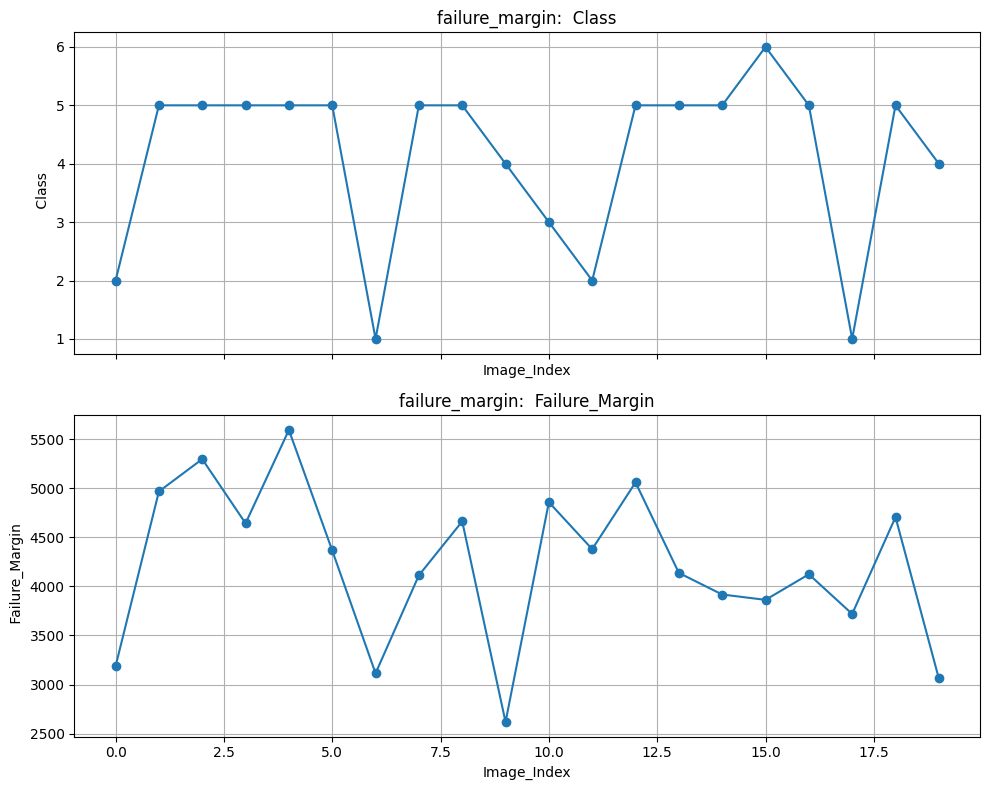

In [5]:
#more detailed plot with subplots if multiple columns
if num_df.shape[1] > 2 or (num_df.shape[1] == 2 and x_col is None):
    n_cols = num_df.shape[1] if x_col is None else num_df.shape[1] - 1
    fig, axs = plt.subplots(n_cols, 1, figsize=(10, 4 * n_cols), sharex=(x_col is not None))
    if n_cols == 1:
        axs = [axs]
    plot_idx = 0
    for col in num_df.columns:
        if col == x_col:
            continue
        ax = axs[plot_idx]
        if x_col is not None:
            ax.plot(num_df[x_col], num_df[col], marker='o', label=str(col))
            ax.set_xlabel(str(x_col))
        else:
            ax.plot(num_df.index, num_df[col], marker='o', label=str(col))
            ax.set_xlabel("row index")
        ax.set_ylabel(str(col))
        ax.set_title(f"failure_margin: {col}")
        ax.grid(True)
        plot_idx += 1
    plt.tight_layout()
    out_png_detailed = path.with_name(path.stem + "_detailed.png")
    plt.savefig(out_png_detailed, dpi=200)
    print(f"Detailed plot saved to {out_png_detailed}")
    plt.show()

Rotation results pie chart saved to ../results/results_rotation.png


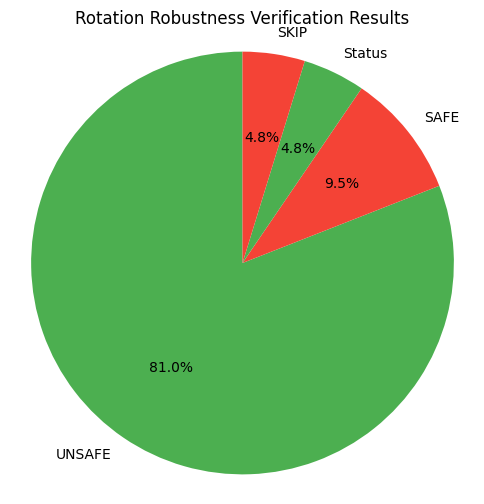

Failed angles histogram saved to ../results/results_rotation_failed_angles_histogram.png


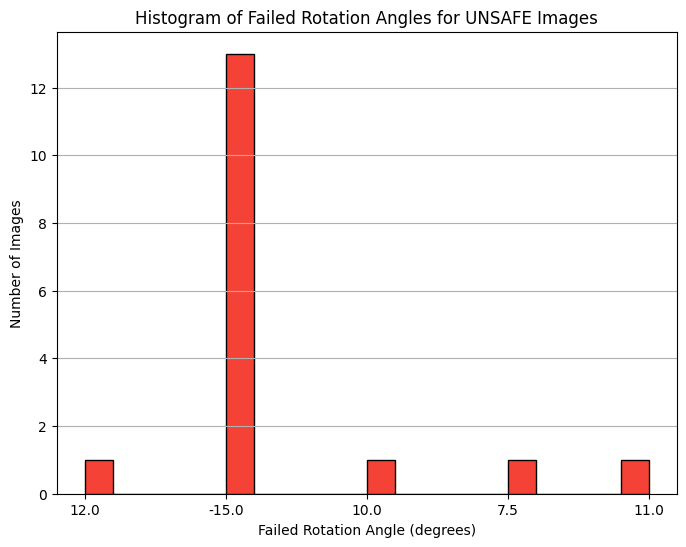

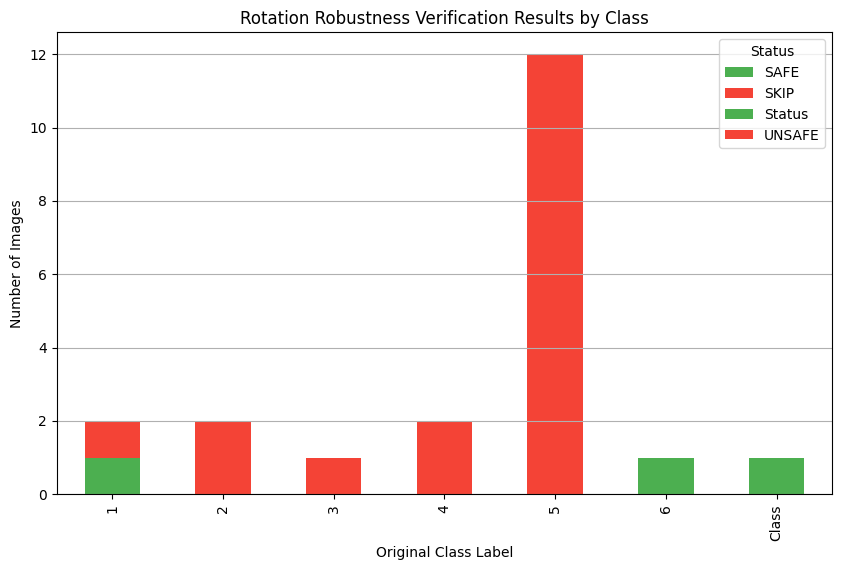

In [8]:
#visualization of ../results/results_rotation.txt
import pathlib
import pandas as pd
import matplotlib.pyplot as plt 
path = pathlib.Path("../results/results_rotation.txt")
if not path.exists():
    raise FileNotFoundError(f"{path} not found")
df = pd.read_csv(path, sep=",", header=None, names=["ImageIndex", "OriginalLabel", "Status", "FailedAngle"])
status_counts = df["Status"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%", startangle=90, colors=["#4CAF50", "#F44336"])
plt.title("Rotation Robustness Verification Results")
plt.axis("equal")
out_png = path.with_suffix(".png")
plt.savefig(out_png, dpi=200)
print(f"Rotation results pie chart saved to {out_png}")
plt.show()

#another graph: histogram of failed angles for UNSAFE images
unsafe_df = df[df["Status"] == "UNSAFE"]
if not unsafe_df.empty:
    plt.figure(figsize=(8, 6))
    plt.hist(unsafe_df["FailedAngle"], bins=20, color="#F44336", edgecolor="black")
    plt.title("Histogram of Failed Rotation Angles for UNSAFE Images")
    plt.xlabel("Failed Rotation Angle (degrees)")
    plt.ylabel("Number of Images")
    plt.grid(axis="y")
    out_png_hist = path.with_name(path.stem + "_failed_angles_histogram.png")
    plt.savefig(out_png_hist, dpi=200)
    print(f"Failed angles histogram saved to {out_png_hist}")
    plt.show()


#more detailed bar chart of safe vs unsafe per class
class_counts = df.groupby(["OriginalLabel", "Status"]).size().unstack(fill_value=0)
class_counts.plot(kind="bar", stacked=True, figsize=(10, 6), color=["#4CAF50", "#F44336"])
plt.title("Rotation Robustness Verification Results by Class")
plt.xlabel("Original Class Label")
plt.ylabel("Number of Images")
plt.legend(title="Status")
plt.grid(axis="y")
plt.show()

Plot saved as 'rotation_plot.png'


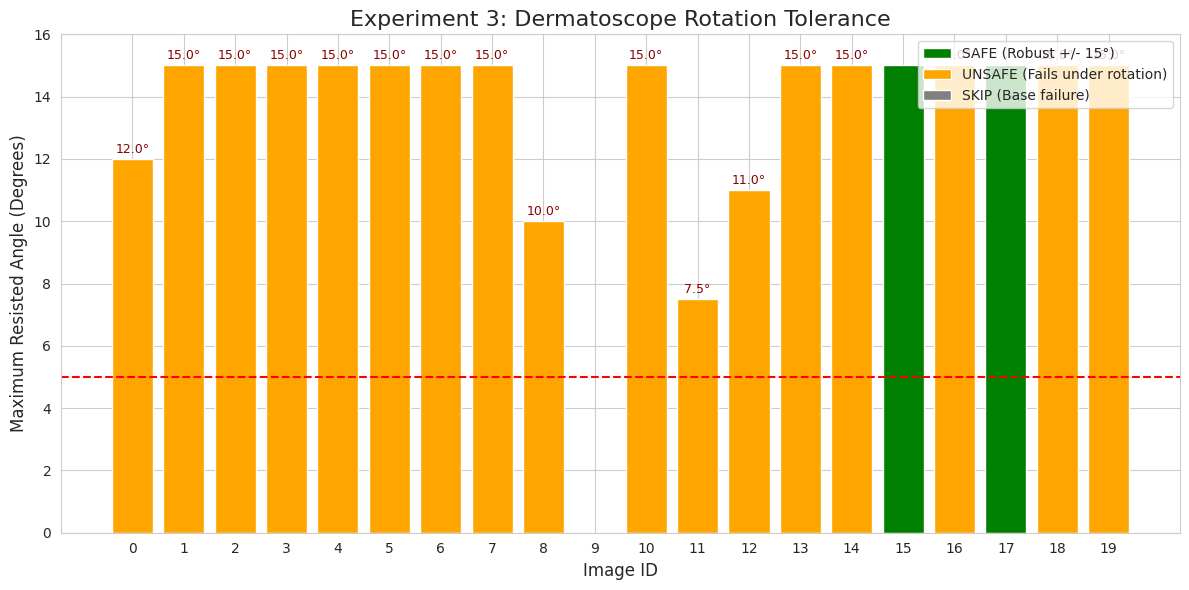

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def plot_rotation_results():
    # 1. Read the generated file
    try:
        df = pd.read_csv("../results/results_rotation.txt")
    except FileNotFoundError:
        print("Error: results_rotation.txt not found")
        return

    # 2. Process data for the plot
    # We want to visualize "Resistance": absolute value of the failure angle.
    # If it's SAFE, assign the maximum (15.0).
    # If it's SKIP, assign 0.
    rotation_limit = 15.0

    def get_resistance(row):
        if row['Status'] == 'SAFE':
            return rotation_limit
        elif row['Status'] == 'SKIP':
            return 0
        else:
            return abs(float(row['FailAngle']))

    df['Resistance'] = df.apply(get_resistance, axis=1)

    # Colors by status
    colors = df['Status'].map({'SAFE': 'green', 'UNSAFE': 'orange', 'SKIP': 'gray'})

    # 3. Configure plot
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    # Bar chart
    bars = plt.bar(df['ImageID'], df['Resistance'], color=colors)

    # Critical line: less than 5 degrees is unacceptable
    plt.axhline(y=5, color='red', linestyle='--', label='High Risk Zone (<5°)')

    # Decoration
    plt.title('Experiment 3: Dermatoscope Rotation Tolerance', fontsize=16)
    plt.xlabel('Image ID', fontsize=12)
    plt.ylabel('Maximum Resisted Angle (Degrees)', fontsize=12)
    plt.xticks(df['ImageID'])
    plt.ylim(0, 16)

    # Manual legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', label='SAFE (Robust +/- 15°)'),
        Patch(facecolor='orange', label='UNSAFE (Fails under rotation)'),
        Patch(facecolor='gray', label='SKIP (Base failure)')
    ]
    plt.legend(handles=legend_elements, loc='upper right')

    # Add text labels for UNSAFE bars
    for i, row in df.iterrows():
        if row['Status'] == 'UNSAFE':
            plt.text(i, row['Resistance'] + 0.2, f"{row['Resistance']}°",
                     ha='center', fontsize=9, color='darkred')

    plt.tight_layout()
    plt.savefig('rotation_plot.png', dpi=300)
    print("Plot saved as 'rotation_plot.png'")

if __name__ == "__main__":
    plot_rotation_results()